# Проект. Автоматизированная витрина данных для Яндекс Такси

- Автор: *Наталья Мартынова*
- Дата: *июль 2026 года*

Каждый день компания обрабатывает миллионы поездок, оплаченных разными способами. Чтобы финансовая и продуктовая команды регулярно получали актуальные данные о выручке и поведении пассажиров, коллеги решили настроить автоматическую обработку этих данных.

Цель — построить витрину данных, которая будет агрегировать информацию о поездках по каждому способу оплаты. 

Задачи:
- написать PySpark-скрипт, который рассчитает ключевые показатели: количество поездок, среднюю стоимость поездки, средние чаевые и суммарную выручку по каждому типу оплаты
- создать DAG в Airflow, который будет проверять наличие новых файлов с данными, запускать Spark-задачу, формировать обновлённую итоговую таблицу.

Эта таблица станет основой для финансовых отчётов и аналитических дашбордов.

## 1. Настройка Spark-агрегации

In [ ]:
# Так как мы будем впоследствии записывать итоговую агрегацию в ClickHouse, 
# нужно предварительно создать там пустую таблицу с соответствующим названием, полями и типами данных

CREATE TABLE taxi_payment_summary
(
    payment_type String PRIMARY KEY,
    trips_count Int64,
    avg_fare Float32,
    avg_tips Float32,
    sum_total Float32
)
ENGINE = MergeTree();

# Запускаю этот код в DBeaver в соответствующей базе данных и убеждаюсь, что пустая таблица создана

SELECT *
FROM taxi_payment_summary
LIMIT 10;

Теперь непосредственно пишем Spark-скрипт:

In [ ]:
# Выполняем необходимые импорты
from pyspark.sql import SparkSession
from pyspark.sql import functions as F 

# Создаём Spark-сессию, добавляем конфигурации для подключения к S3, задаём минимальные ресурсы для Spark‑приложения
spark = (SparkSession.builder.appName("myAggregateTest")
    .config("fs.s3a...")
    .config("spark.dynamicAllocation.enabled", "false")
    .config("spark.executor.instances", "1")
    .config("spark.executor.cores", "1")
    .config("spark.executor.memory", "1g")
    .config("spark.driver.memory", "1g")
    .getOrCreate())

# Путь к файлу c исходными данными в формате Parquet
parquet_path = "s3a://.../taxi_data.parquet"

# Читаем Parquet-файл из s3, сохраняем данные в датафрейм
df = spark.read.parquet(parquet_path)

# Выполняем требуемую агрегацию: 
taxi_payment_summary = df.groupBy("payment_type").agg( # Группируем данные по полю payment_type
    F.count("*").alias("trips_count"), # Рассчитываем количество поездок
    F.avg("fare").alias("avg_fare"), # Рассчитываем среднюю стоимость
    F.avg("tips").alias("avg_tips"), # Рассчитываем средние чаевые 
    F.sum("trip_total").alias("sum_total") # Рассчитываем суммарную выручку
)

# Порт и параметры кластера ClickHouse
jdbcPort = ...
jdbcHostname = "..."
username = "..."
password = "..."
jdbcDatabase = "..." 
jdbcUrl = f"jdbc:clickhouse://{jdbcHostname}:{jdbcPort}/{jdbcDatabase}?ssl=true"

# Настраиваем запись полученной таблицы в ClickHouse
taxi_payment_summary.write.format("jdbc") \ # Инициализируем запись через JDBC-драйвер
    .option("url", jdbcUrl) \ # Адрес, по которому Spark подключается к БД, хранится в переменной jdbcUrl
    .option("user", username) \ # Логин для авторизации в БД - в переменной username
    .option("password", password) \ # Пароль для авторизации в БД
    .option("dbtable", "taxi_payment_summary") \ # Название таблицы, в которую будут записываться данные
    .mode('append') \ # Запись будет происходить в режиме добавления строк к таблице базы данных")
    .save() # Запускаем процесс записи

## 2. Настройка DAG

In [ ]:
# Необходимые импорты
from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator


DAG_ID = "taxi_data_analysis" # Уникальный идентификатор нашего DAG

# Создаём граф
with DAG(
    DAG_ID,
    schedule='@daily', # Расписание запуска графа
    start_date=datetime(2025, 1, 1), # Логическая дата старта
    catchup=False # Пересчёт прошедших периодов отключён
) as dag: # Ниже идут задачи
    # 1) Ждём появления входного файла в S3 с помощью сенсора S3KeySensor
    wait_for_input = S3KeySensor(
        task_id='wait_for_s3_sensor', # Уникальный идентификатор задачи
        bucket_name="...", # Имя бакета в облачном хранилище, где нужно проверить наличие файла
        bucket_key="....parquet", # Путь к файлу, который нужно обнаружить
        aws_conn_id='s3', # Идентификатор подключения к s3 в Airflow
        poke_interval=300, # Частота проверки сенсором наличия файла 
        timeout=3600, # Максимальное время ожидания файла
        mode="poke", # Режим работы сенсора (всё время активен)
        wildcard_match=False # Настройка трактования bucket_key (сенсор ищет точное совпадение)
    )

    user = '...' # Логин для подключения

    # 2) Запускаем PySpark-задачу
    run_pyspark = DataprocCreatePysparkJobOperator( # Используем оператор для запуска Spark-приложения на кластере прямо из Airflow
        task_id="run_pyspark_job", # Уникальный идентификатор задачи
        name="pyspark_job", # Название задачи
        cluster_id="...", # Идентификатор кластера, на котором будет выполняться Spark-приложение
        main_python_file_uri=f"s3a://.../{user}/....py" # Путь к PySpark-скрипту в облачном хранилище
    )

    # 3)  Зависимости 
    wait_for_input >> run_pyspark # Очерёдность выполнения зависящих друг от друга задач

## 3. Запусr DAG с помощью Airflow UI

В интерфейсе Apache Airflow находим наш DAG и запускаем. Проверяем, что DAG выполнился, а результат соответствует ожиданиям.

Обе задачи графа выполнились успешно:


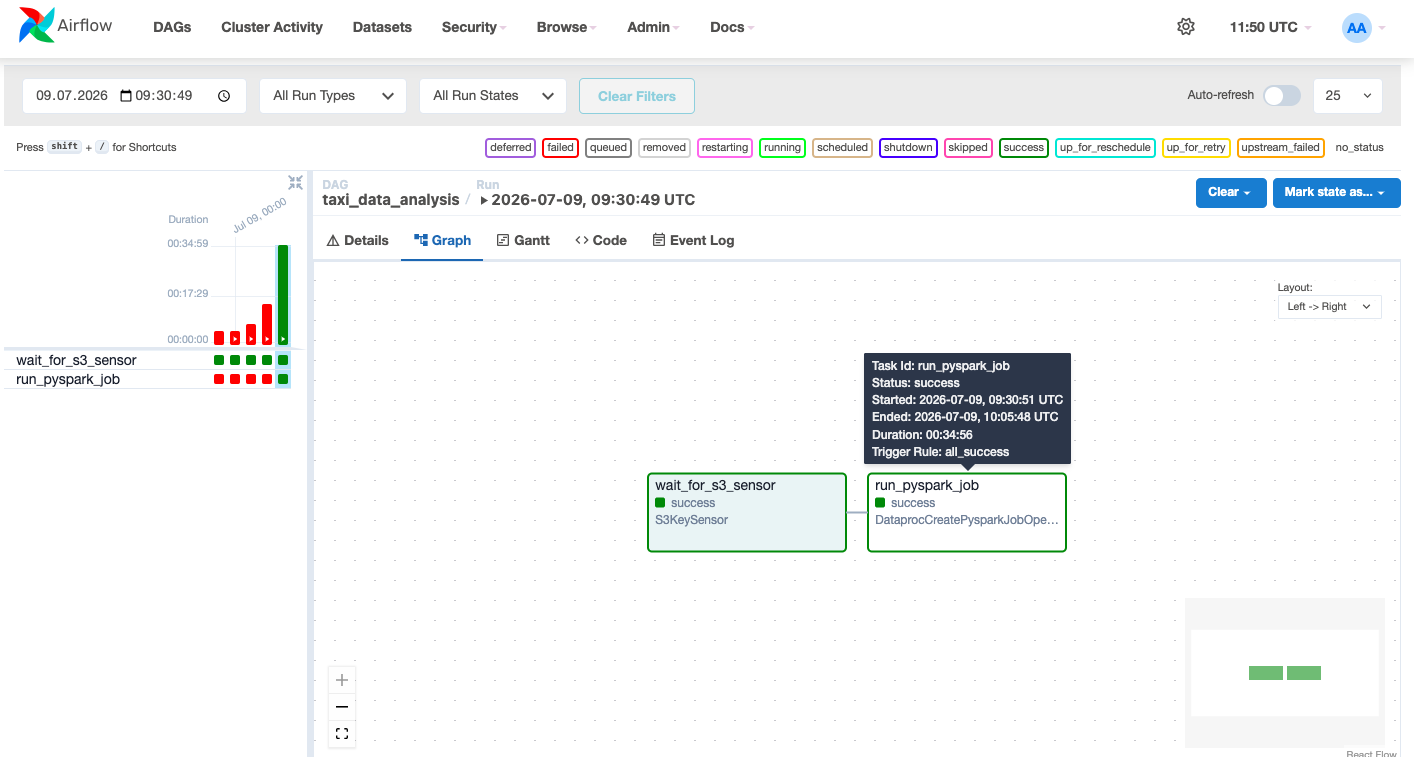

Таблица с агрегированными данными записалась в ClickHouse (проверяем в DBeaver):

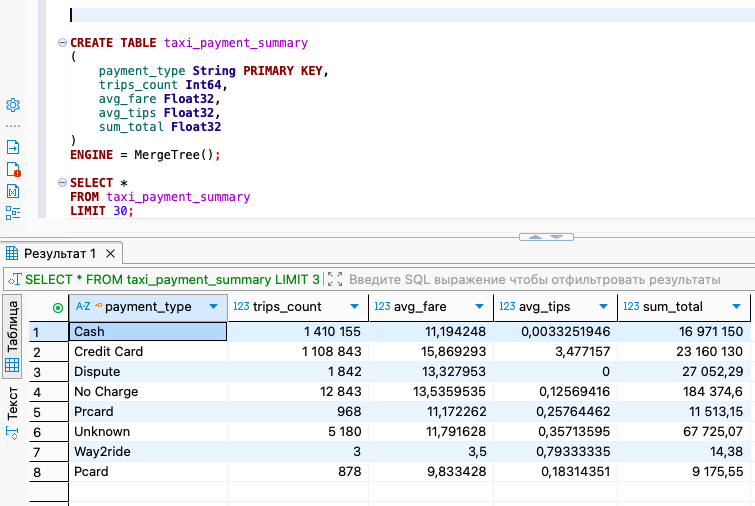
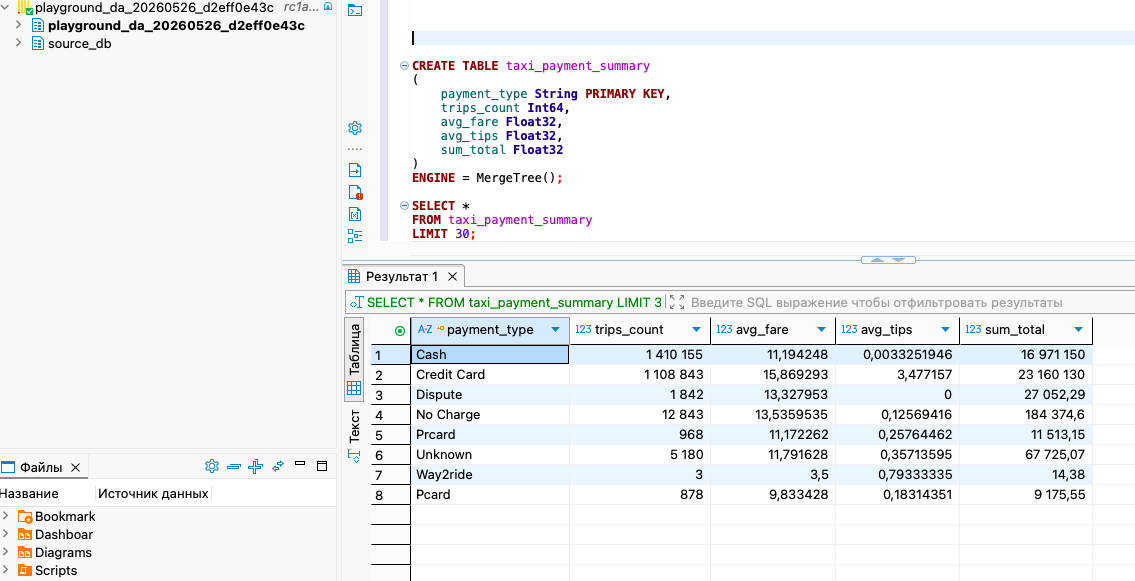